<a href="https://colab.research.google.com/github/PreciousAkpokighe/AI-ML-Training-course-professional-programme-with-Imperial-College-London/blob/main/Self_study_try_it_activity_23_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Self-study try-it activity 23.1: Data processing for PCA

PCA is a dimensionality reduction technique that captures the highest possible variance from a set number of dimensions. Additionally, it will find the projection that minimises the sum of the squared distances between the original and the projected data points.

In [1]:
#Import the necessary libraries
import numpy.random as rand
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


Below is a simulated data set (shown in blue) that has been projected onto four different components (shown in orange).

Which of these projections maximises the variance of the data that is kept and is likely to be the principal component?

This activity helps you visually identify the direction that captures the most variance – an essential concept in understanding how PCA selects principal components.

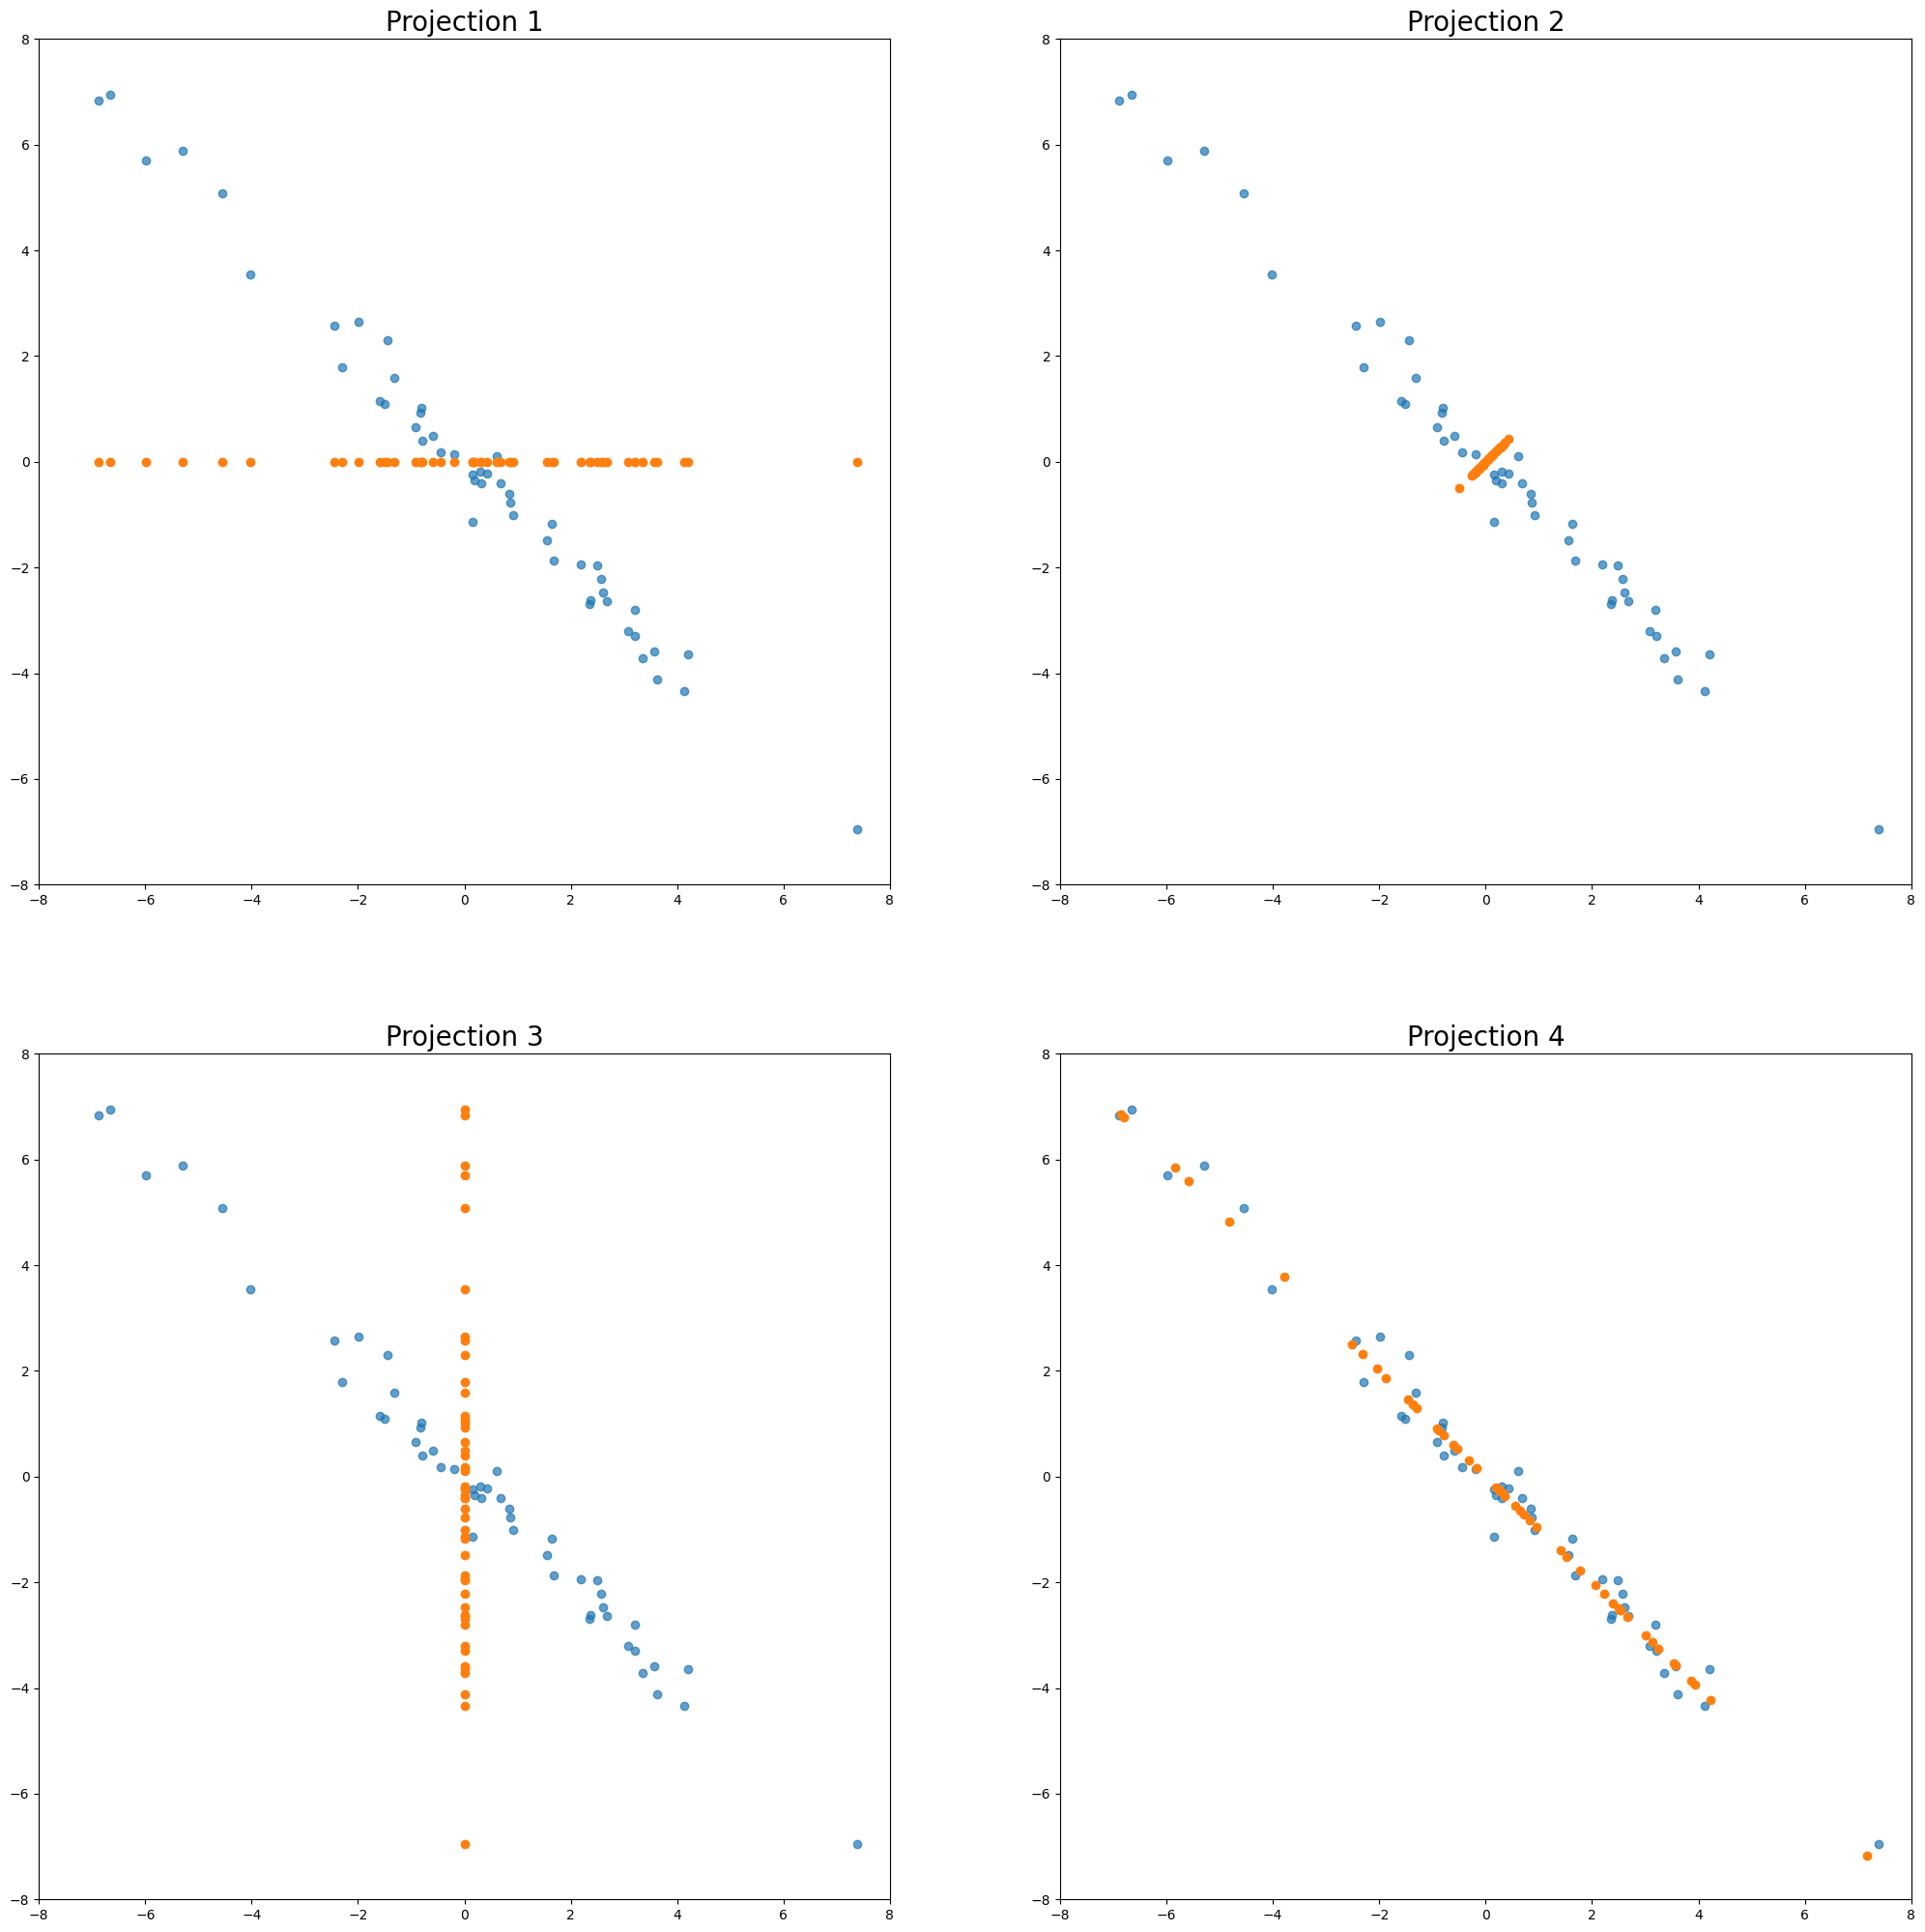

In [2]:
rand.seed(1234)

x1 = 3 * np.outer(rand.normal(0,1,50), np.array([1,-1]))
x2 = rand.multivariate_normal([0,0],np.diag([0.1,0.1]), size = 50)

X = x1 + x2

projection = np.array((1,0)).reshape((2,1))

R = np.matrix([[1/np.sqrt(2), -1/np.sqrt(2)], [1/np.sqrt(2), 1/np.sqrt(2)]])

fig, axs = plt.subplots(2,2, figsize = (25,25))
for i in range(4):
    axs[i//2, i % 2 ].set_xlim([-8,8])
    axs[i//2, i % 2 ].set_ylim([-8,8])
    axs[i//2, i % 2 ].scatter(X[:,0], X[:,1], alpha = 0.7)
    axs[i//2, i % 2 ].title.set_text("Projection %s" % (i+1))
    axs[i//2, i % 2 ].title.set_size(20)
    scores = X @ projection
    Xi = np.outer(scores, projection)
    axs[i//2, i % 2 ].scatter(Xi[:,0],Xi[:,1])
    projection = R @ projection

plt.show()


 ### To-do 1:
 Which of these projections maximises the variance of the data that is kept and is likely to be the principal component?

* Projection 1
* Projection 2
* Projection 3
* Projection 4


### Type your answer here:

**Projection 1** maximises the variance of the data that is kept and is therefore most likely to be the principal component. This projection shows the data spread along a clear diagonal axis, indicating the direction where the data exhibits the most variability.

## Dimensionality reduction with PCA

PCA is commonly used to reduce the dimensionality of high-dimensional data sets by selecting a subset of components that retain most of the original variance. This technique is particularly valuable when preparing data for machine learning models, as it can improve training efficiency and model generalisation.

In this notebook, you will work with a data set comprising S&P 500 stock prices over the past five years. Given the high degree of correlation among stocks in the market, retaining all individual stock features may introduce redundancy and unnecessarily increase model complexity and training time.

Instead, PCA allows you to project the data onto a smaller set of orthogonal components that capture the majority of the variance. This approach simplifies the feature space while preserving the underlying structure, making it a more effective input for downstream modelling tasks.


In [4]:
df = pd.read_csv("all_stocks_5yr.csv")

names = df["Name"].unique()
range(len(df[ df["Name"] == names[0]]["close"]))
l = len(df[ df["Name"] == names[0]]["close"])
data = pd.DataFrame(index = range(l), columns= names)

for name in names:
    x = df[ df["Name"] == name]["close"]
    if x.isnull().any() or len(x) != l:
        data = data.drop(columns= name)
    else:
        data[name] = np.array(x)

data.head()

,AAL,AAPL,AAP,ABBV,ABC,ABT,ACN,ADBE,ADI,ADM,...,XLNX,XL,XOM,XRAY,XRX,XYL,YUM,ZBH,ZION,ZTS
0,14.75,67.8542,78.90,36.25,46.89,34.41,73.31,39.12,45.70,30.22,...,37.51,28.24,88.61,42.87,31.84,27.09,65.30,75.85,24.14,33.05
1,14.46,68.5614,78.39,35.85,46.76,34.26,73.07,38.64,46.08,30.28,...,37.46,28.31,88.28,42.84,31.96,27.46,64.55,75.65,24.21,33.26
2,14.27,66.8428,78.60,35.42,46.96,34.30,73.37,38.89,46.27,30.81,...,37.58,28.41,88.46,42.87,31.84,27.95,64.75,75.44,24.49,33.74
3,14.66,66.7156,78.97,35.27,46.64,34.46,73.56,38.81,46.26,31.16,...,37.80,28.42,88.67,43.08,32.00,28.26,64.41,76.00,24.74,33.55
4,13.99,66.6556,78.84,36.57,46.77,34.70,73.13,38.61,46.54,31.40,...,38.44,28.22,88.52,42.91,32.12,28.47,63.89,76.34,24.63,33.27


The above code cell loads five years of S&P 500 stock data and constructs a clean data frame of closing prices, excluding stocks with missing values or inconsistent time series lengths. The result is a well-aligned data set suitable for analysis or modelling.

## Interpreting the scree plot

The scree plot below displays the proportion of variance explained by each of the first ten principal components derived from the PCA of the stock data set. This visualisation is a key tool for determining the optimal number of components to retain.

Your task is to analyse the scree plot and decide how many principal components you would keep to effectively represent the data set while minimising dimensionality. Consider both the individual and cumulative variance explained and identify the 'elbow point' – the point beyond which additional components contribute marginally to the total variance.

### To-do 2:

Based on the scree plot of the first ten principal components from the PCA and any additional analysis you consider appropriate, how many components would you retain to effectively represent this data set, and what is your rationale for that choice?


Component 1 
Fraction of total variance explained by this variable: 0.783705370360257 
 Total fraction of variance explained by the first 1 variable(s): 0.783705370360257

Component 2 
Fraction of total variance explained by this variable: 0.09162218072840872 
 Total fraction of variance explained by the first 2 variable(s): 0.8753275510886658

Component 3 
Fraction of total variance explained by this variable: 0.05430341223767854 
 Total fraction of variance explained by the first 3 variable(s): 0.9296309633263443

Component 4 
Fraction of total variance explained by this variable: 0.02084533802414898 
 Total fraction of variance explained by the first 4 variable(s): 0.9504763013504933

Component 5 
Fraction of total variance explained by this variable: 0.012893002325176692 
 Total fraction of variance explained by the first 5 variable(s): 0.96336930367567

Component 6 
Fraction of total variance explained by this variable: 0.008528095295358334 
 Total fraction of variance explained 

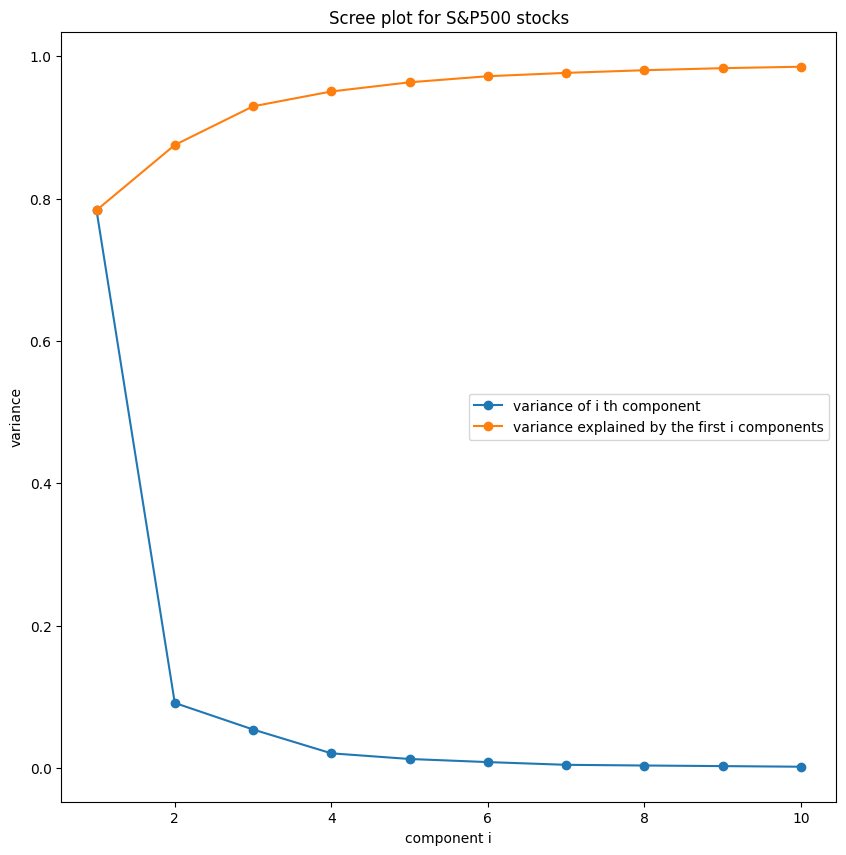

In [5]:
pca = PCA(10).fit(data)
var = pca.explained_variance_ratio_
var_explained = np.zeros(10)
for i in range(10):
    var_explained[i] = sum(var[:i+1])

for i in range(10):
    print("\nComponent", i+1 , "\nFraction of total variance explained by this variable:", var[i],
            "\n Total fraction of variance explained by the first %s variable(s):" % (i +1), var_explained[i] )

plt.figure(figsize = (10,10))
plt.plot(range(1, len(var_explained)+1), var, label = "variance of i th component", marker = "o")
plt.plot(range(1, len(var_explained)+1), var_explained, label = "variance explained by the first i components", marker = "o")
plt.xlabel("component i")
plt.ylabel("variance")
plt.title("Scree plot for S&P500 stocks")
plt.legend()
plt.show()




Based on the scree plot of the first ten principal components from the PCA of the **raw data**, I would recommend retaining **1 to 3 components** to effectively represent this data set.

Here's my rationale:

1.  **High Variance Explained by the First Component**: The first principal component (PC1) alone explains a substantial **78.37%** of the total variance. This indicates that a single component already captures a very large proportion of the overall information in the dataset.

2.  **Clear 'Elbow Point'**: The scree plot clearly shows a sharp 'elbow' after the first component. The explained variance drops significantly from PC1 (78.37%) to PC2 (9.16%). While PC2 adds to the cumulative variance, the rate of additional variance explained by subsequent components diminishes rapidly.

3.  **Cumulative Variance Consideration**: If we look at the cumulative variance:
    *   **1 Component**: Explains 78.37% of the variance.
    *   **2 Components**: Cumulatively explain 78.37% + 9.16% = **87.53%** of the variance.
    *   **3 Components**: Cumulatively explain 87.53% + 5.43% = **92.96%** of the variance.

    Retaining even just one component captures a large majority of the variance. Adding a second component boosts this significantly, getting close to 90%. Including a third component pushes the cumulative explained variance over 90%, which is often a common threshold for retaining sufficient information. Beyond three components, each additional component contributes a much smaller fraction of the remaining variance (e.g., PC4 adds only 2.08%).

Therefore, depending on the specific requirements for information retention versus dimensionality reduction, one could argue for keeping 1, 2, or 3 components. Given the significant drop after the first, and then a more gradual decline, 2 or 3 components would likely offer a good balance between reducing dimensionality and preserving most of the data's variability.

## Pre-processing the data

When analysing which stocks contribute most to the principal components, it's important to consider how the data was pre-processed. If you apply PCA directly to the raw closing prices, stocks with higher average prices dominate the principal components in raw data because PCA is sensitive to scale. This can lead to misleading interpretations, as variance may reflect price magnitude rather than meaningful movement.

In most financial analyses, you are more interested in **relative variability**, which means how much a stock's price fluctuates in proportion to its own value rather than its absolute magnitude. A high variance driven by a large price scale does not necessarily indicate meaningful movement or volatility.

To ensure a fair and interpretable PCA, you standardise the data so that each stock has a **mean of zero** and a **variance of one**. This transformation allows PCA to focus on patterns of variation that are comparable across stocks, regardless of their original price levels, leading to more meaningful insights.


## Re-evaluating component selection

### To-do 3:

Examine the scree plot provided below. Based on its structure and the variance explained by each principal component, can you reasonably assume that the same number of components should be retained as in your previous PCA? Consider whether the distribution of variance has changed and justify your conclusion with reference to the plot.


Component 1
Fraction of total variance explained by this component:0.5831
Total fraction of variance explained by the first 1 component(s): 0.5831

Component 2
Fraction of total variance explained by this component:0.1492
Total fraction of variance explained by the first 2 component(s): 0.7323

Component 3
Fraction of total variance explained by this component:0.1014
Total fraction of variance explained by the first 3 component(s): 0.8337

Component 4
Fraction of total variance explained by this component:0.0387
Total fraction of variance explained by the first 4 component(s): 0.8724

Component 5
Fraction of total variance explained by this component:0.0252
Total fraction of variance explained by the first 5 component(s): 0.8976

Component 6
Fraction of total variance explained by this component:0.0190
Total fraction of variance explained by the first 6 component(s): 0.9166

Component 7
Fraction of total variance explained by this component:0.0132
Total fraction of variance explained 

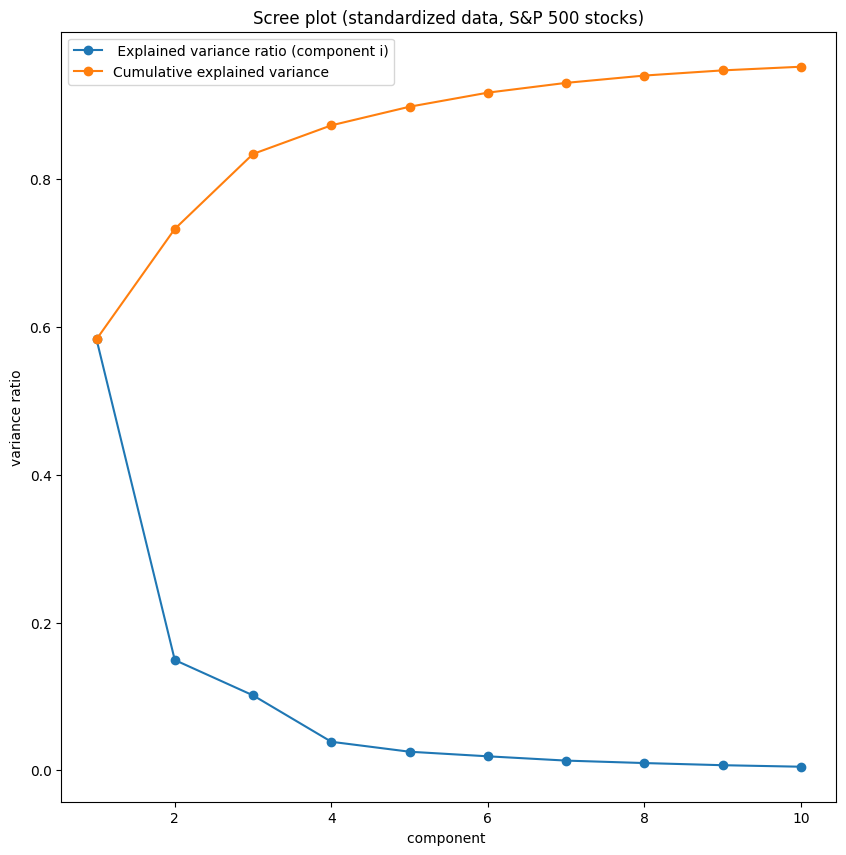

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().fit(data)


data_scaled = scaler.transform(data)

#Number of component guards (optional but safer)
n_comp = min(10, data_scaled.shape[1])
pca_scaled = PCA(n_comp).fit(data_scaled)
var_scaled = pca_scaled.explained_variance_ratio_
var_scaled_explained = np.cumsum(var_scaled)

#Print the scaled values you just computed
for i in range(n_comp):
    print(
            f"\nComponent {i+1}"
            f"\nFraction of total variance explained by this component:{var_scaled[i]:.4f}"
            f"\nTotal fraction of variance explained by the first {i+1} component(s): {var_scaled_explained[i]:.4f}"
        )
#Plot using the scaled arrays for both series and axis length
plt.figure(figsize=(10, 10))
plt.plot(range(1, n_comp+1), var_scaled, marker="o", label=" Explained variance ratio (component i)")
plt.plot(range(1, n_comp+1), var_scaled_explained, marker="o", label="Cumulative explained variance")
plt.xlabel("component ")
plt.ylabel("variance ratio")
plt.title("Scree plot (standardized data, S&P 500 stocks)")
plt.legend()
plt.show()

Based on the scree plot of the standardized data, it is **not reasonable to assume that the same number of components should be retained** as in the previous PCA (with raw data).

Here's why:

1.  **Shift in Variance Distribution**: When comparing the `var` (variance explained by individual components) and `var_explained` (cumulative variance explained) values from the raw data PCA to the `var_scaled` and `var_scaled_explained` values from the standardized data PCA, a clear shift in the distribution of variance is evident.

    *   **Raw Data**: The first principal component alone explained approximately 78.37% of the total variance. The cumulative variance reached about 92.96% with just the first three components.
    *   **Standardized Data**: The first principal component now explains only about 58.31% of the total variance. To achieve a similar cumulative explained variance (e.g., around 90-93%), more components are required. For instance, to reach approximately 92.99% cumulative variance, we now need 7 components.

2.  **Less Pronounced "Elbow Point"**: In the scree plot for the raw data, there was a very sharp drop in explained variance after the first component, indicating a clear 'elbow' and suggesting that a small number of components (perhaps 1 or 2) captured a vast majority of the variance. In contrast, the scree plot for the standardized data shows a more gradual decline in explained variance across the initial components. The 'elbow point' is less distinct, implying that variance is more evenly distributed among the principal components. This is a direct consequence of standardizing the data, which gives equal weight to the variance of each stock, rather than allowing high-priced stocks to dominate.

**Conclusion**: Due to the more even distribution of variance and the less sharp drop-off, a larger number of principal components would likely need to be retained from the standardized data to capture a similar proportion of the total variance as was captured by a smaller number of components from the raw data. This highlights the importance of pre-processing for a meaningful PCA, as it changes the underlying structure that PCA captures.

## Comparing PCA results: raw vs pre-processed data

Applying PCA to raw versus pre-processed data can yield significantly different principal components. This distinction is illustrated below through two key observations:

1. **Top-contributing stocks**:  
   When you examine the five stocks that contribute most to the first principal component, you find that the results differ between the raw and standardised data sets. This indicates that the PCA model identifies different sources of variance depending on whether the data has been scaled.

2. **Score distribution across components**:  
   The plots of scores along the first two principal components may appear visually similar, but the underlying scales differ substantially. In the standardised data, features are adjusted to have equal variance, which can amplify or compress certain patterns. This transformation leads to a more balanced and interpretable representation of the data structure.

These differences highlight the importance of pre-processing when applying PCA, especially in contexts where feature magnitudes vary widely.


### To-do 4:

Imagine you are an investor planning to allocate capital across S&P 500 stocks based on their weights in the first principal component derived from historical data. However, recognising the potential risk due to high variance in returns, you decide to mitigate this by splitting your investment: half based on the first principal component and half based on the second, which is uncorrelated with the first and exhibits lower variance.

Given this strategy, would it be more appropriate to derive the principal components from the **raw data** or from **pre-processed (standardized) data**? Justify your answer regarding interpretability, risk, and the nature of PCA.


Largest 5 contributors to the principal component of unpreprocessed data: Index(['PCLN', 'AMZN', 'GOOGL', 'MTD', 'EQIX'], dtype='object')
Largest 5 contributors to the principal component of preprocessed data: Index(['CTAS', 'BDX', 'AVGO', 'LMT', 'NOC'], dtype='object')


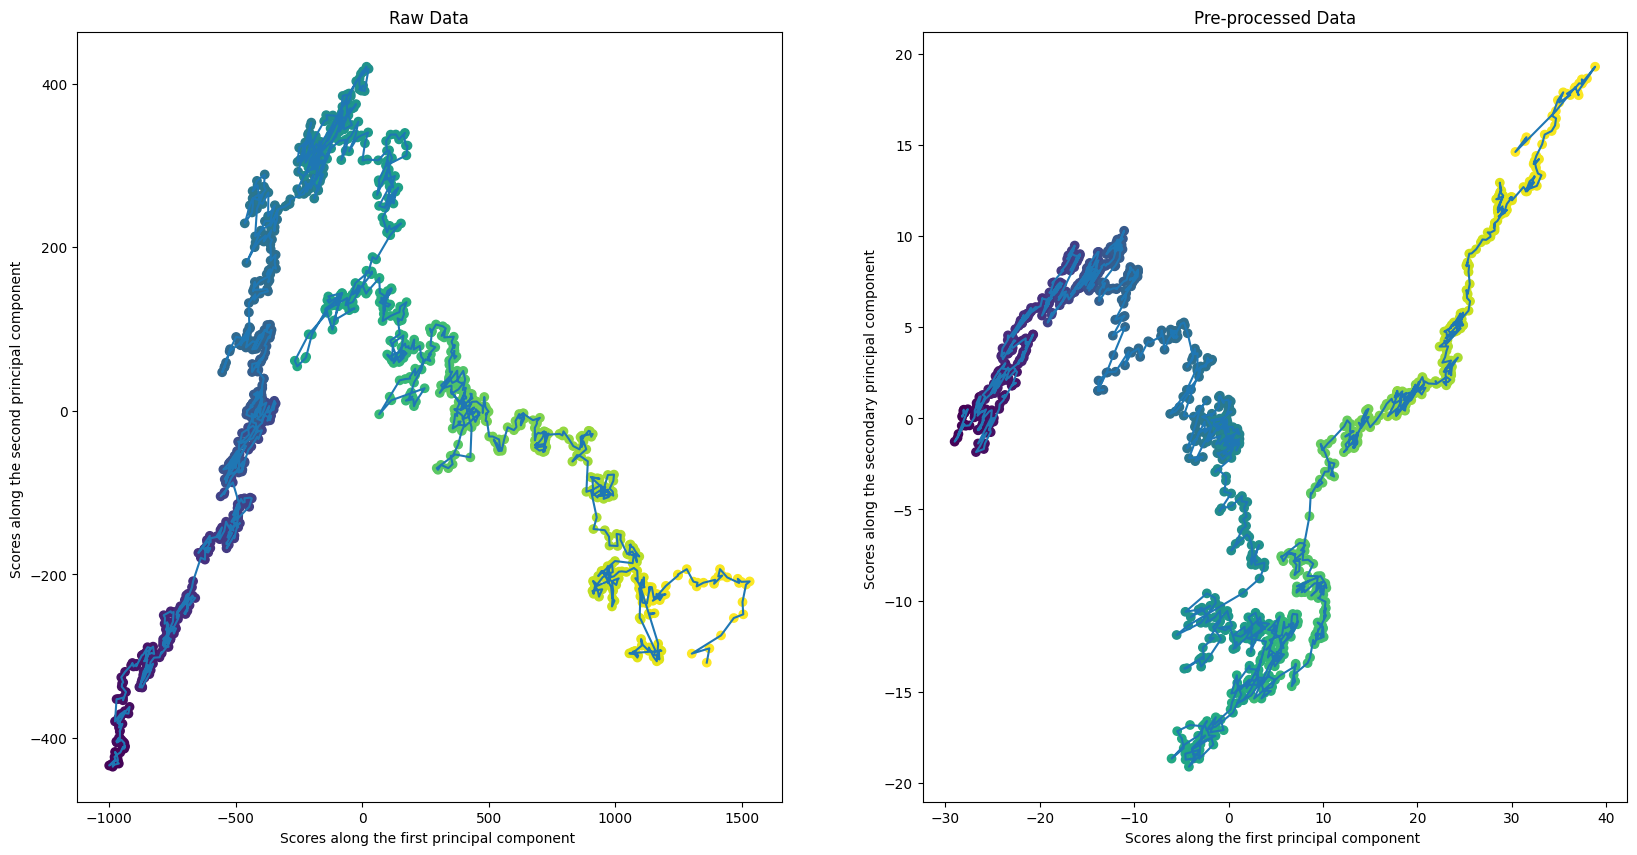

83.69295150457137


In [7]:
stocks = data.columns[np.argsort(pca.components_[0])[-1:-6:-1]]

print("Largest 5 contributors to the principal component of unpreprocessed data:", stocks)

stocks_scaled = data.columns[np.argsort(pca_scaled.components_[0])[-1:-6:-1]]

print("Largest 5 contributors to the principal component of preprocessed data:", stocks_scaled)

fig, axs = plt.subplots(1,2, figsize = (20,10))
axs[0].plot(pca.transform(data)[:,0],pca.transform(data)[:,1])
axs[0].scatter(pca.transform(data)[:,0],pca.transform(data)[:,1], c = np.arange(l)/l)
axs[1].plot(pca_scaled.transform(data_scaled)[:,0],pca_scaled.transform(data_scaled)[:,1])
axs[1].scatter(pca_scaled.transform(data_scaled)[:,0],pca_scaled.transform(data_scaled)[:,1], c = np.arange(l)/l)
axs[0].set_title("Raw Data")
axs[1].set_title("Pre-processed Data")
axs[0].set_xlabel("Scores along the first principal component ")
axs[0].set_ylabel("Scores along the second principal component ")
axs[1].set_xlabel("Scores along the first principal component ")
axs[1].set_ylabel("Scores along the secondary principal component ")
plt.show()
print(np.mean(data))

### Type your answer here:
For your investment strategy, it would be more appropriate to derive the principal components from **pre-processed (standardized) data**.

Here's why, considering interpretability, risk, and the nature of PCA:

1.  **Interpretability**: When using raw data, stocks with higher absolute prices (and thus often higher variance in absolute terms) will disproportionately influence the principal components. This can lead to the first principal component primarily reflecting overall market movement driven by a few high-priced stocks. While this might capture a large portion of the variance, it doesn't necessarily represent the *relative* movements or underlying risk factors across all stocks in a balanced way.

    With **standardized data**, each stock's price series is scaled to have a mean of zero and a standard deviation of one. This equalizes the playing field, ensuring that the principal components capture variance based on the *relative fluctuations* and correlation structure of the stocks, rather than their absolute price magnitudes. This leads to more meaningful and interpretable components that reflect genuine co-movements and risk factors across the entire portfolio of stocks.

2.  **Risk Mitigation**: The goal of splitting your investment between the first and second principal components is to mitigate risk due to high variance. If you use raw data, the first principal component will likely be dominated by the absolute price movements of a few large, high-value stocks. Investing in this could still expose you to concentrated risk related to those specific stocks. The second component would also be influenced by the raw scales.

    By using **standardized data**, the principal components become more robust measures of underlying market factors. The first principal component will capture the strongest common factor (e.g., overall market sentiment or a broad sector trend) that drives the most significant *relative* variance across stocks. The second component will then capture the next most significant *uncorrelated* factor. Since standardization removes the influence of absolute price levels, the components better represent systemic risk factors that are comparable across different stocks, allowing for more effective diversification and risk management when allocating capital based on these factors.

3.  **Nature of PCA**: PCA is sensitive to the scale of the features. If features are on different scales (as raw stock prices undoubtedly are), features with larger variances (i.e., higher-priced stocks) will tend to dominate the principal components, regardless of their actual importance in terms of relative movement. Standardizing the data is a crucial pre-processing step that addresses this inherent sensitivity, making the PCA results more robust and relevant for financial analysis where relative performance and correlations are often more important than absolute price levels.

In summary, while raw data PCA might capture overall market movements driven by large stocks, **standardized data PCA provides a more balanced and interpretable view of the underlying variance and risk factors across the entire S&P 500.** This aligns better with an investment strategy focused on diversifying across uncorrelated principal components to mitigate risk.


